#Homework 2 Assignment

##1.) Implement a Decision Tree Classifier for your classification problem. You may use a built-in package to implement your classifier. Additionally, do the following:


###1.0) Get load Dataset from Hw1

In [114]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("volodymyrgavrysh/fraud-detection-bank-dataset-20k-records-binary")

print("Path to dataset files:", path)
!cp -r "$path" /content/
path = kagglehub.dataset_download("volodymyrgavrysh/fraud-detection-bank-dataset-20k-records-binary")

print("Path to dataset files:", path)
!cp -r "$path" /content/

Using Colab cache for faster access to the 'fraud-detection-bank-dataset-20k-records-binary' dataset.
Path to dataset files: /kaggle/input/fraud-detection-bank-dataset-20k-records-binary
Using Colab cache for faster access to the 'fraud-detection-bank-dataset-20k-records-binary' dataset.
Path to dataset files: /kaggle/input/fraud-detection-bank-dataset-20k-records-binary


In [115]:
import pandas as pd;
df = pd.read_csv("/content/fraud-detection-bank-dataset-20k-records-binary/fraud_detection_bank_dataset.csv")
print("dataset")
df = pd.concat([df.iloc[:, :26], df.iloc[:, -1]], axis=1) # reduce runtim
df=df.drop(columns={"Unnamed: 0"})
df=df.rename(columns={"col_1": "Amount($)"})
df = df.sample(frac=1)
df.head()

dataset


,col_0,Amount($),col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,targets
18527,2,166,0,4,0,0,0,2,0,0,...,1,0,0,0,0,0,2,21,4,0
18043,4,101,0,2,0,0,-1,4,0,0,...,0,0,0,0,0,0,7,14,1,0
8852,0,158,0,4,0,0,6,0,0,0,...,0,0,0,0,0,0,0,8,3,0
3991,0,68,0,1,0,2,0,0,0,0,...,1,0,0,0,0,0,0,3,2,1
19774,0,9,0,1,0,1,-1,0,0,0,...,0,0,0,0,0,0,0,5,1,0


###1.1) Visualize the decision tree structure for at least three different parameter settings. Comment on how the depth and complexity change the tree.

####Data Processing

In [116]:
X = df.drop(columns=['targets'])
y = df['targets']

# summarize the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(16374, 25) (4094, 25)
(16374,) (4094,)


####Big Model

In [167]:
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

# define the model
big_Model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=100)
# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=1, random_state=1)
n_scores = cross_val_score(big_Model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print(f"Test Accuracy: {100*round(mean(n_scores),4)}%")
# fit the model on the whole dataset

big_Model.fit(X, y)


big_y_pred = big_Model.predict(X_test)
print(f"Test Accuracy: {100*round(accuracy_score(y_test, big_y_pred),4)}%")
print(f"Model depth: {big_Model.get_depth()}")

Test Accuracy: 85.24000000000001%
Test Accuracy: 86.86%
Model depth: 10


####Model 1

In [168]:
model_1 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3000)
cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=1, random_state=1)
n_scores = cross_val_score(model_1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
print(f"Test Accuracy: {100*round(mean(n_scores),4)}%")

model_1.fit(X, y)

print(f"Model depth: {model_1.get_depth()}")
m1_y_pred = model_1.predict(X_test)
print(f"Test Accuracy: {round(accuracy_score(y_test, m1_y_pred),3)}%")

Test Accuracy: 76.55%
Model depth: 3
Test Accuracy: 0.841%


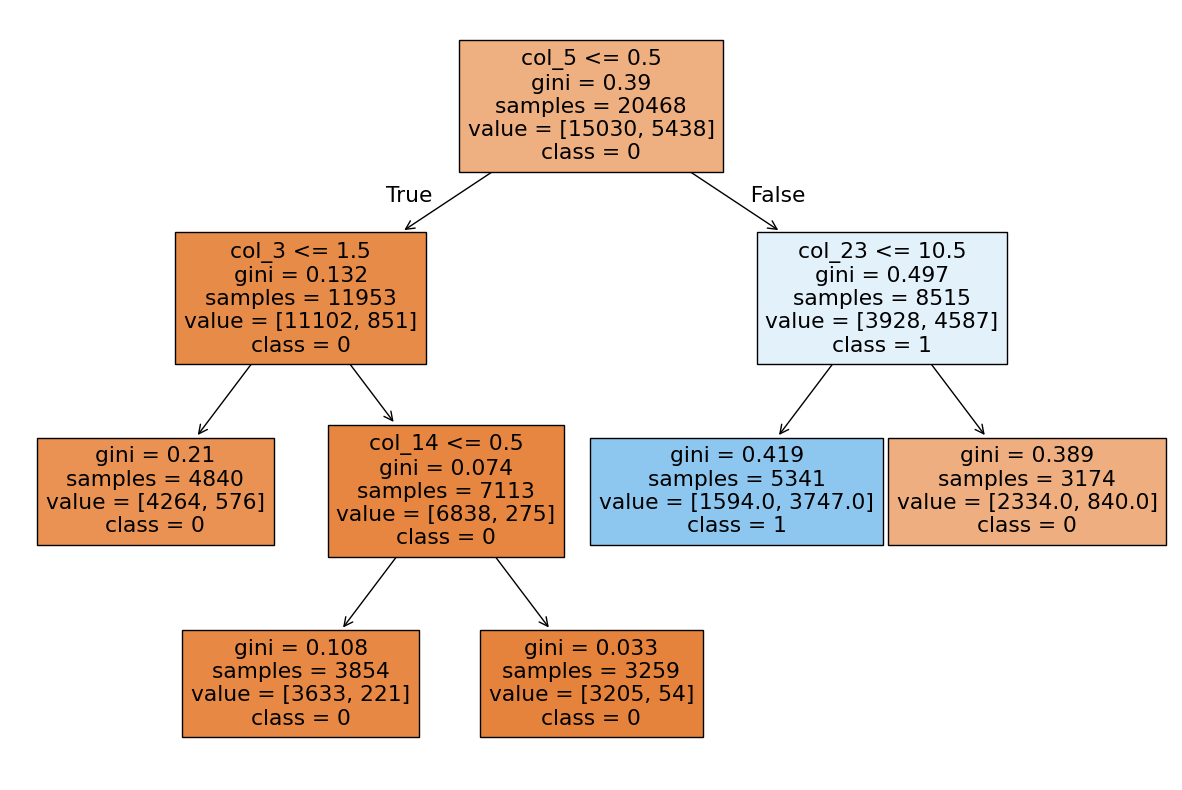

In [119]:
fig = plt.figure(figsize=(15,10))
_ = plot_tree(model_1,
              feature_names=X.columns.tolist(),
              class_names=['0', '1'],
              filled=True)
plt.show()

####Model 2

In [164]:
model_2 = DecisionTreeClassifier(max_depth=3)
cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=1, random_state=1)
n_scores = cross_val_score(model_2, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
print(f"Test Accuracy: {100*round(mean(n_scores),4)}%")

model_2.fit(X, y)


m2_y_pred = model_2.predict(X_test)
print(f"Test Accuracy: {100*round(accuracy_score(y_test, m2_y_pred),4)}%")
print(f"Model depth: {model_2.get_depth()}")

Accuracy: 0.848 (0.005)
Model depth: 3
Test Accuracy: 85.52%


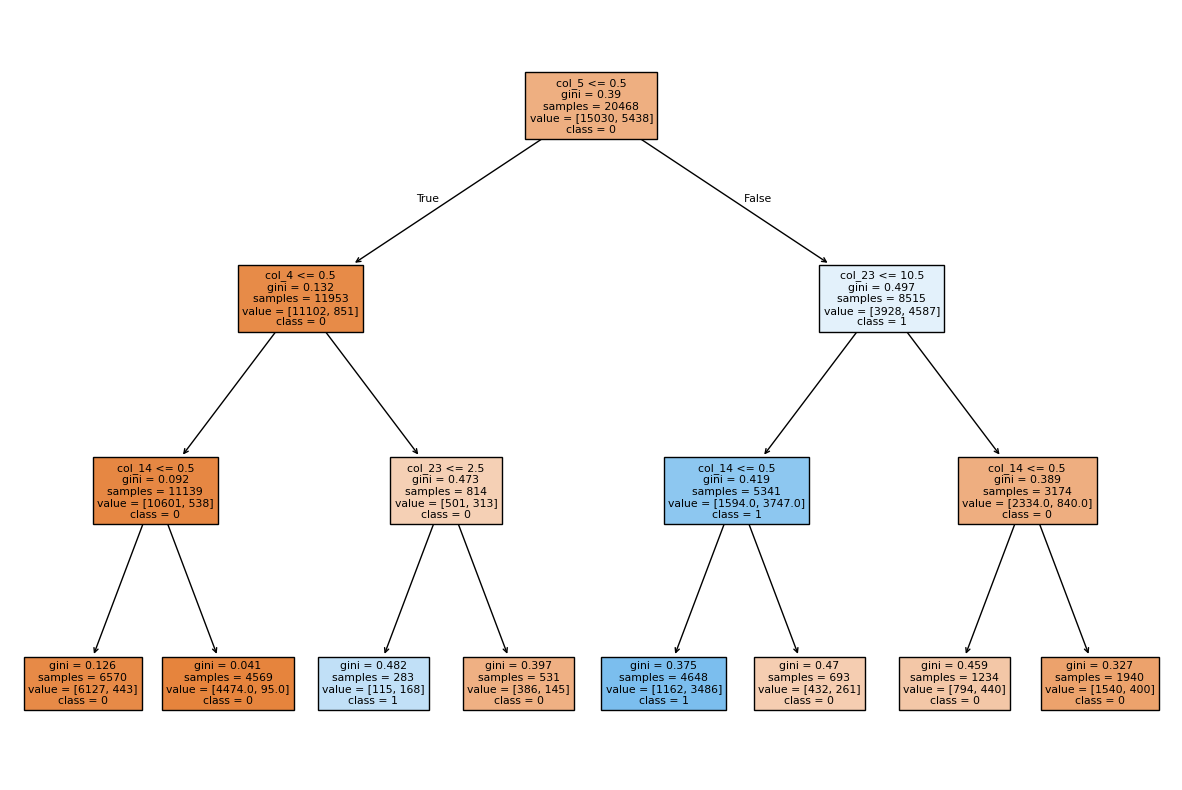

In [121]:
fig = plt.figure(figsize=(15,10))
_ = plot_tree(model_2,
              feature_names=X.columns.tolist(),
              class_names=['0', '1'],
              filled=True)
plt.show()

####Model 3

In [169]:
model_3 = DecisionTreeClassifier(max_depth=2)
cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=1, random_state=1)
n_scores = cross_val_score(model_3, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
print(f"Test Accuracy: {100*round(mean(n_scores),4)}%")

model_3.fit(X, y)

m3_y_pred = model_3.predict(X_test)
print(f"Test Accuracy: {100*round(accuracy_score(y_test, m3_y_pred),4)}%")
print(f"Model depth: {model_3.get_depth()}")

Test Accuracy: 83.94%
Test Accuracy: 84.15%
Model depth: 2


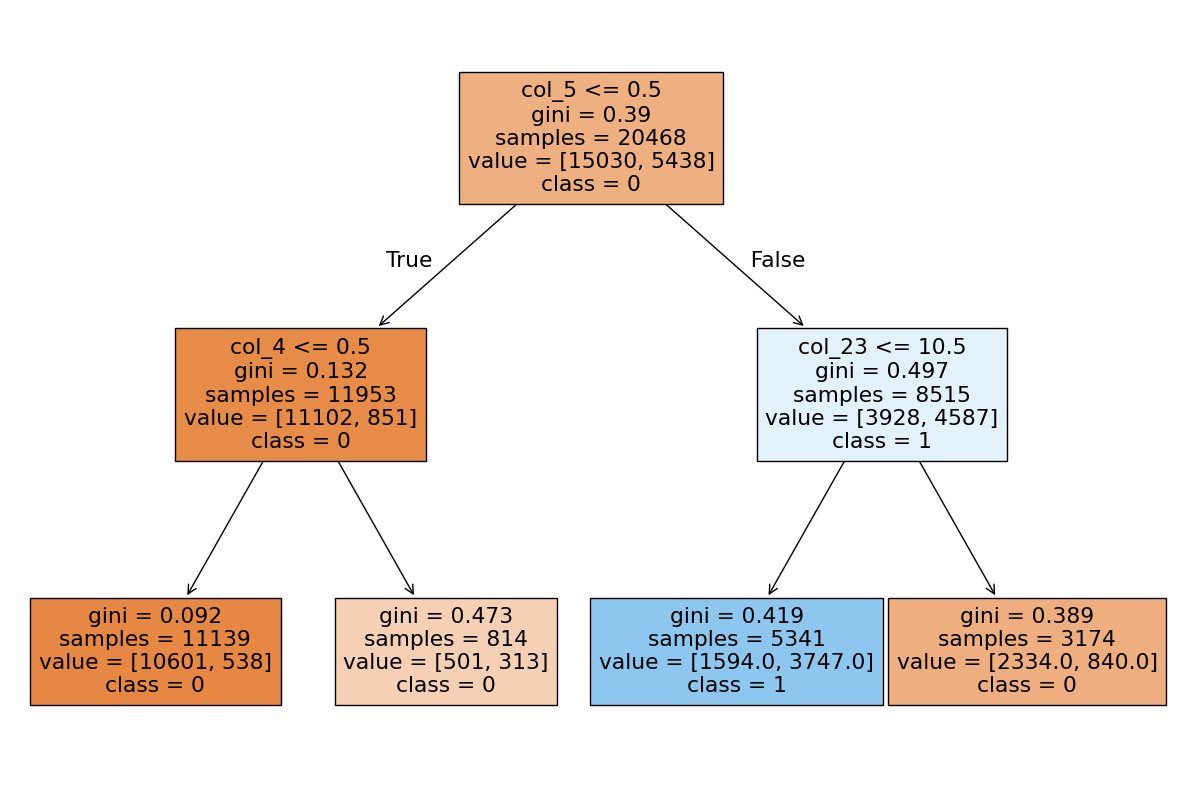

In [123]:
fig = plt.figure(figsize=(15,10))
_ = plot_tree(model_3,
              feature_names=X.columns.tolist(),
              class_names=['0', '1'],
              filled=True)
plt.show()

####Comments on hyper parremeters

---


Max depth Changes how far down the tree can get restricting the model to only applying at max d tests on the data before determening its classification. Min Sample Leaf helps to reduce tree complexity only allowing the tree to split if thier is enough data. This helps it to not overfit on the data having to find patternes that generize well.

###1.2) Do some research on what sensitivity analysis is and how it is performed (include citations). Perform a sensitivity analysis to measure the impact of at least two input features on your model's decision boundary.


####Explination
A Senstivity Analasis is an analaysis that determense what affect a change in a specific input variable affects a given output variable.

$\frac{Change in Input Varaible}{Change in Output Varaible}$

To preform this we simply isolate 1 input variabial freezing the rest and then see how that affects the outcome of our funciton.

https://www.investopedia.com/terms/s/sensitivityanalysis.asp

####Implimination

#####Feature 1: Amount($)

In [124]:
import random
import copy

In [125]:
import warnings
warnings.filterwarnings("ignore")
org_pred = 1
new_pred = 1
change = 0
amountChangeInInput = 10
trials = 10000
for i in range(trials):
  row_idx = random.choice(df.index)
  row_org = df.loc[row_idx].to_numpy()
  row_org = row_org[:-1]
  row_org = row_org.reshape(1, 25)
  row_new = copy.deepcopy(row_org)
  row_new[0][1]+=amountChangeInInput
  org_pred = big_Model.predict(row_org)
  new_pred = big_Model.predict(row_new)
  if(org_pred>new_pred):
    change-=1
  if(org_pred<new_pred):
    change+=1
amountChangeInOutput= change/trials
print(f"Change in output {amountChangeInInput}")
print(f"Change in output {amountChangeInOutput}")
print(f"Model sencitivity to Amount = {round(amountChangeInOutput/amountChangeInInput,6)}")

Change in output 10
Change in output 0.0147
Model sencitivity to Amount = 0.00147


#####Feature 2: col_24

In [126]:
import warnings
warnings.filterwarnings("ignore")
org_pred = 1
new_pred = 1
change = 0
amountChangeInInput = 5
trials = 10000
for i in range(trials):
  row_idx = random.choice(df.index)
  row_org = df.loc[row_idx].to_numpy()
  row_org = row_org[:-1]
  row_org = row_org.reshape(1, 25)
  row_new = copy.deepcopy(row_org)
  row_new[0][23]+=amountChangeInInput
  org_pred = big_Model.predict(row_org)
  new_pred = big_Model.predict(row_new)
  if(org_pred>new_pred):
    change-=1
  if(org_pred<new_pred):
    change+=1
amountChangeInOutput= change/trials
print(f"Change in output {amountChangeInInput}")
print(f"Change in output {amountChangeInOutput}")
print(f"Model sencitivity to Col_24 = {round(amountChangeInOutput/amountChangeInInput,6)}")

Change in output 5
Change in output -0.0829
Model sencitivity to Col_24 = -0.01658


#####Feature 3: col_5

In [127]:
import warnings
warnings.filterwarnings("ignore")
org_pred = 1
new_pred = 1
change = 0
amountChangeInInput = 2
trials = 10000
for i in range(trials):
  row_idx = random.choice(df.index)
  row_org = df.loc[row_idx].to_numpy()
  row_org = row_org[:-1]
  row_org = row_org.reshape(1, 25)
  row_new = copy.deepcopy(row_org)
  row_new[0][4]+=amountChangeInInput
  org_pred = big_Model.predict(row_org)
  new_pred = big_Model.predict(row_new)
  if(org_pred>new_pred):
    change-=1
  if(org_pred<new_pred):
    change+=1
amountChangeInOutput= change/trials
print(f"Change in output {amountChangeInInput}")
print(f"Change in output {amountChangeInOutput}")
print(f"Model sencitivity to Col_4 = {round(amountChangeInOutput/amountChangeInInput,6)}")

Change in output 2
Change in output 0.0601
Model sencitivity to Col_4 = 0.03005


##2.) From the Bagging and Boosting ensemble methods pick any one algorithm from each category. Implement both the algorithms using the same data.

###2.1) Use stratified k-fold cross-validation with at least three different folds (e.g., 5, 10, 15). You may do your own research on this technique (include citations).


https://www.geeksforgeeks.org/machine-learning/stratified-k-fold-cross-validation/

In [128]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "f1": "f1_weighted"
    }
model_1_y_pred = cross_val_predict(big_Model, X, y, cv=skf)
confusion_mat_1 = confusion_matrix(y, model_1_y_pred)
model_1_scores = cross_validate(big_Model, X, y, cv=skf, scoring=scoring)

In [129]:
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "f1": "f1_weighted"
    }
model_2_y_pred = cross_val_predict(big_Model, X, y, cv=skf)
confusion_mat_2 = confusion_matrix(y, model_2_y_pred)
model_2_scores = cross_validate(big_Model, X, y, cv=skf, scoring=scoring)

In [130]:
skf = StratifiedKFold(
    n_splits=15,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "f1": "f1_weighted"
    }
model_3_y_pred = cross_val_predict(big_Model, X, y, cv=skf)
confusion_mat_3 = confusion_matrix(y, model_3_y_pred)
model_3_scores = cross_validate(big_Model, X, y, cv=skf, scoring=scoring)

###2.2) Evaluate the models using any three-evaluation metrics of your choice (e.g. accuracy, Precision, F1-score etc.).

####Accuracy

In [131]:
print(f"Model 1 Accuracy {model_1_scores["test_accuracy"].mean()}")
print(f"Model 2 Accuracy {model_2_scores["test_accuracy"].mean()}")
print(f"Model 3 Accuracy {model_3_scores["test_accuracy"].mean()}")

Model 1 Accuracy 0.8606117824097309
Model 2 Accuracy 0.8613937569750167
Model 3 Accuracy 0.861638469057824


####Percision

In [132]:
print(f"Model 1 Percision {model_1_scores["test_precision"].mean()}")
print(f"Model 2 Percision {model_2_scores["test_precision"].mean()}")
print(f"Model 3 Percision {model_3_scores["test_precision"].mean()}")

Model 1 Percision 0.8566140083185451
Model 2 Percision 0.8575401411922327
Model 3 Percision 0.858019151786761


####F1-Score

In [133]:
print(f"Model 1 F1-Score {model_1_scores["test_f1"].mean()}")
print(f"Model 2 F1-Score {model_2_scores["test_f1"].mean()}")
print(f"Model 3 F1-Score {model_3_scores["test_f1"].mean()}")

Model 1 F1-Score 0.8552274092465453
Model 2 F1-Score 0.8554111290234753
Model 3 F1-Score 0.855336974379327


###2.3) Comment on the behavior of each algorithm under the metrics. Does the performance ranking change based on the metric used? Why?


The models preformace for all metrix improve the more folds we add. This is because a single bad train test split brings down the average less when we have more folds. The model also sees more of the dataset with more folds. However preformance is very similar across models improvements bieng less than 0.01.

##3.)Compare the effectiveness of the three models implemented above. Analyze the results using the following:

###3.1) A confusion matrix for one selected test fold.

####Model1

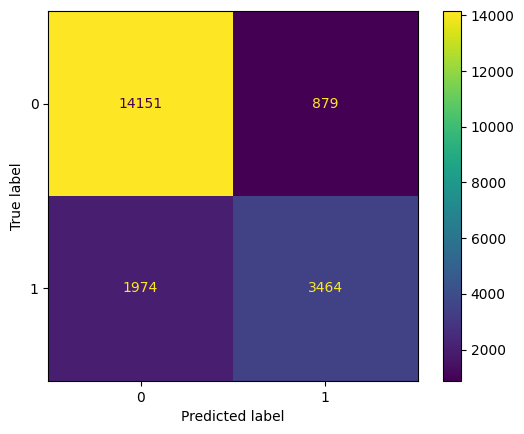

In [134]:
import matplotlib.pyplot as plt
from sklearn.metrics import  ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat_1)

disp.plot()

plt.show()

####Model 2

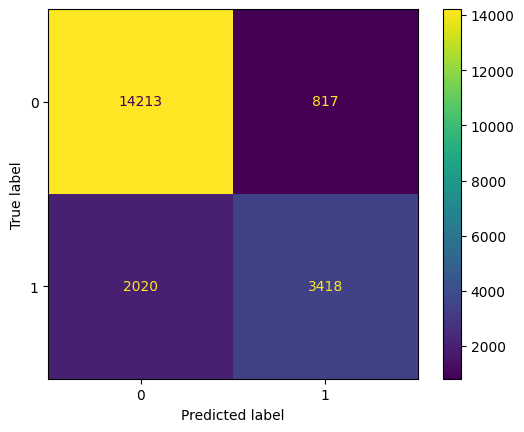

In [135]:
import matplotlib.pyplot as plt
from sklearn.metrics import  ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat_2)

disp.plot()

plt.show()

####Model 3

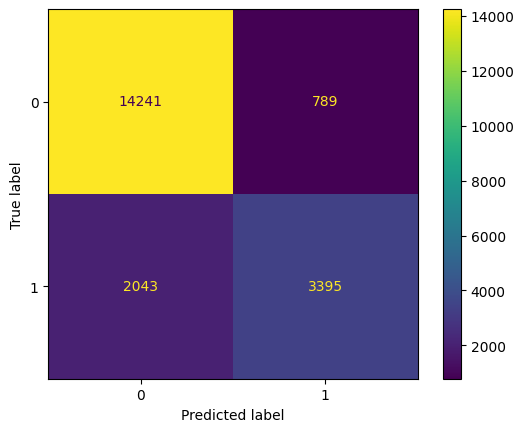

In [136]:
import matplotlib.pyplot as plt
from sklearn.metrics import  ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat_3)

disp.plot()

plt.show()

###3.2) A statistical test (e.g., paired t-test) to determine if differences between models are significant.

In [170]:
import scipy.stats as stats

print(f"Model_1 Vs Model_2, pvalue={stats.ttest_rel(m1_y_pred, m2_y_pred).pvalue}. Signifigant difference.")
print(f"Model_1 Vs Model_3, pvalue={stats.ttest_rel(m1_y_pred, m3_y_pred).pvalue}. No difference.")
print(f"Model_2 Vs Model_3, pvalue={stats.ttest_rel(m2_y_pred, m3_y_pred).pvalue}. Signifigant difference")
print(f"Model_2 Vs Model_3, pvalue={stats.ttest_rel(big_y_pred, m2_y_pred).pvalue}. Very Signifigant difference")

Model_1 Vs Model_2, pvalue=8.04126863214416e-05. Signifigant difference.
Model_1 Vs Model_3, pvalue=nan. No difference.
Model_2 Vs Model_3, pvalue=8.04126863214416e-05. Signifigant difference
Model_2 Vs Model_3, pvalue=3.9645510993270546e-24. Very Signifigant difference


###3.3) A discussion on the trade-off between bias and variance for each model.

Variance and Bais are the two main indicators of the training phenomenoms Overfitting and Underfitting.


UnderFitting

---


To much bais ussualy occures when the model is just bad at catching patterns in the data due to bieng to simple.

OverFitting

---


To much variance is when the model is so tuned to the training data that it picks up on patters in the noise of the data set and not actual realworld patterns.

So simply put to much variance is a sign off to overtraining and to much bias is a sign of to little training. When Bias goes down variance goes up. When doing real world problems we can find the correct balance by having a test dataset to gage the models performace on realworld data.